# Does gold really make all its money while you sleep? 🌙🥇
### The sleeping-gold legend, measured honestly — in plain English

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Ever harvestable?: Busted](https://img.shields.io/badge/Ever_harvestable%3F-Busted-8b949e?style=flat-square)

There's a chart that has floated around gold forums for fifteen years. It splits every trading day in two: the **night** (from the US market close to the next morning's open — the hours when gold trades in Asia and through the London morning "fix") and the **day** (open to close — the London afternoon fix and New York hours). The legend: **all of gold's gains happen at night**, and the day session — the hours when the London fixes were set by a phone call among five banks — gives nothing back or even loses. To believers, that was the smoking gun of price suppression.

We rebuilt that chart from the raw tape — GLD, the big gold ETF, every session since it listed in 2004 — checked it on a second gold fund (IAU), raced it against the stock market (which, as our [study 01](../../01-overnight-anomaly/README.md) showed, has its *own* overnight habit), and then asked the only question that pays: **could anyone have traded it?**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the reform test? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from gold_overnight import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    from quantlab import repro
    WIDE = repro.as_of(data.load_real(), "2026-06-30")
    GLD = data.session_returns(WIDE, "GLD")
    IAU = data.session_returns(WIDE, "IAU")
    SPY = data.session_returns(WIDE, "SPY")
else:
    WIDE = GLD = IAU = SPY = None
print("real gold-overnight cache present:", HAVE_REAL,
      "| GLD sessions:", (0 if GLD is None else len(GLD)))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'fingerprint': '648ab68f37f2', 'reform': '2015-03-20', 'gld': {'start': '2004-11-19', 'end': '2026-06-30', 'n': 5435, 'on': 4.3, 't_on': 4.05, 'id': 0.22, 't_id': 0.22, 'gap': 4.08, 't_gap': 2.94, 'welch': 2.69, 'p': 0.003, 'on_x': 8.63, 'id_x': 0.96, 'on_ann': 10.51, 'id_ann': -0.18, 'cc_ann': 10.31}, 'iau': {'start': '2005-01-31', 'end': '2026-06-30', 'n': 5387, 'on': 5.03, 't_on': 4.63, 'id': -0.35, 't_id': -0.36, 'gap': 5.39, 't_gap': 3.83, 'welch': 3.51, 'p': 0.0002, 'on_x': 12.51, 'id_x': 0.71, 'on_ann': 12.55, 'id_ann': -1.61, 'cc_ann': 10.73}, 'spy': {'start': '2004-11-19', 'end': '2026-06-30', 'n': 5435, 'on': 3.37, 't_on': 3.94, 'id': 1.43, 't_id': 1.29, 'gap': 1.94, 't_gap': 1.38, 'welch': 1.23, 'p': 0.1071, 'on_x': 5.43, 'id_x': 1.72, 'on_ann': 8.16, 'id_ann': 2.56, 'cc_ann': 10.93}, 'gld_pre': (2599, 3.71, 0.64, 3.07, 1.35), 'gld_post': (2836, 4.84, -0.17, 5.01, 2.98), 'iau_pre': (2551, 4.77, -0.15, 4.92, 2.11), 'iau_post': (2836, 5.27, -0.53, 5.81, 3.46), 'gld_change_welch': -0.65, 'iau_change_welch': -0.29, 'vs_spy_welch': 1.0, 'harvest': [(0.5, 3.3, 7.76, 10.31, 3.11), (1.0, 2.3, 5.08, 10.31, 2.17), (2.0, 0.3, -0.08, 10.31, 0.28), (5.0, -5.7, -14.11, 10.31, -5.37)], 'harvest_pre': [(0.5, 6.05), (1.0, 3.41), (2.0, -1.67), (5.0, -15.47)], 'bh_pre': 9.42, 'harvest_post': [(0.5, 9.35), (1.0, 6.63), (2.0, 1.39), (5.0, -12.84)], 'bh_post': 11.13, 'syn': [(0.0, 0.73, 0.47, 0.314), (4.0, 4.73, 3.06, 0.0)]}


real gold-overnight cache present: True | GLD sessions: 5435


## The answer first

| Question | Answer |
|---|---|
| Does gold really gain only overnight? | **Yes — astonishingly so.** Over 21.6 years, $1 riding GLD **only at night** grew to **$8.63**; $1 riding it **only during the day** ended at **$0.96** — below where it started. The stats say this is no fluke. |
| Is that unique to gold? | **Not really.** Stocks (SPY) show the same night-tilt — gold's is about twice as big, but the tape can't prove the difference isn't noise. |
| Did the 2015 clean-up of the London fix end it? | **No — it got *bigger*.** The gap grew after the phone-call fix was replaced by an audited electronic auction. Whatever drives this, it isn't fix-rigging. |
| Could you have traded it? | **No.** Holding only at night means trading **twice every day**. The day session you'd be dodging earns roughly **zero** — so you pay real spreads to avoid nothing. At every cost we tested, the night-only strategy loses to simply **buying and holding gold**. |

> The legend is **true as a description** and **worthless as a trade** — gold does make its money at night, and there is still nothing you can do about it.

## 1 · The claim

> *"For two decades, gold rose overnight and fell (or stalled) during London and New York hours. Buy the PM fix, sell the AM fix, and you'd have captured everything; do the reverse and you'd have lost. The market is rigged during Western hours."*

The chart originates with Adrian Douglas (GATA, 2010), and the respectable version of the mechanism is academic: Caminschi & Heaney (2014) documented information leaking around the London PM fix calls, and in 2014 Barclays was fined for manipulating the fix. In 2015 the century-old phone fix was replaced by an electronic auction — which conveniently gives us a **before/after experiment** on the whole story.

## 2 · So what?

If the pattern is real *and* tradable, it's free money at the expense of whoever sells gold during the day. If it's real but **untradable**, it's something subtler and more interesting: proof that *when* an asset's return arrives on the clock tells you about **where its price discovery happens** (gold's happens in Asia and London, while the US ETF sleeps), not about a hidden hand. And if the 2015 fix reform didn't change it, the manipulation reading loses its engine.

## 3 · How would we even know?

Simple and brutal: take every GLD session from 2004-11-19 to 2026-06-30 (**5,435 days**) and split it in two —

1. **Overnight leg:** yesterday's close → today's open (US market shut).
2. **Intraday leg:** today's open → today's close (London PM fix + NY hours).

The two legs multiply back exactly to the full day, so nothing is lost or double-counted. Then: run each sleeve as its own compounding account, test the night-vs-day gap against luck, check a **second gold fund (IAU)**, race gold against **SPY** (equities have their own night habit — study 01), split at the **2015 fix reform**, and finally charge real trading costs on the "hold only at night" strategy.

## 4 · The teardown — let's actually look

**The legendary chart, rebuilt honestly.** One dollar in GLD, three ways: hold it, hold it only overnight, hold it only during the day.

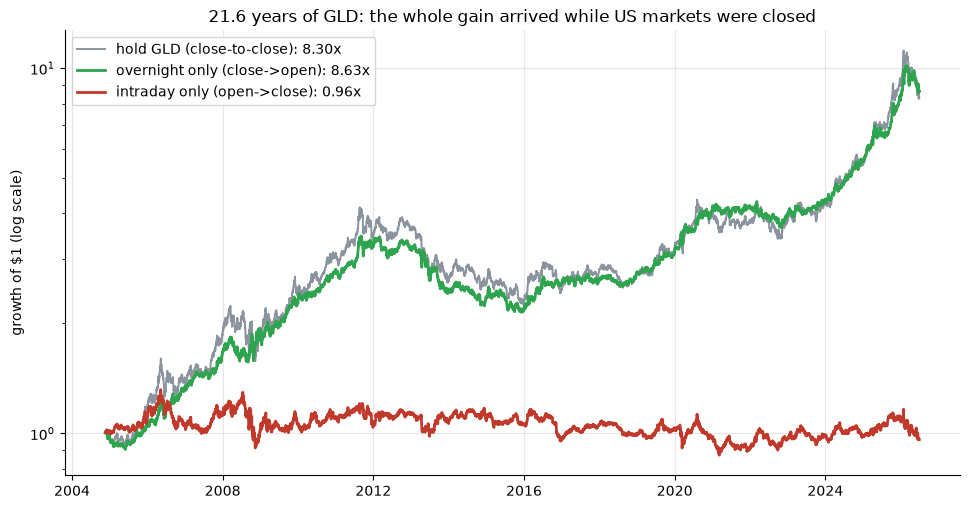

overnight-only 8.63x   intraday-only 0.96x   buy&hold 8.30x


In [2]:
if HAVE_REAL:
    on_curve = (1 + GLD["overnight"]).cumprod()
    id_curve = (1 + GLD["intraday"]).cumprod()
    cc_curve = (1 + GLD["close2close"]).cumprod()
    idx = GLD.index
else:  # illustrative fallback rebuilt from the frozen annualised rates
    idx = pd.bdate_range(R["gld"]["start"], R["gld"]["end"])
    n = len(idx); t = np.arange(1, n + 1) / 252.0
    on_curve = pd.Series((1 + R["gld"]["on_ann"] / 100) ** t, index=idx)
    id_curve = pd.Series((1 + R["gld"]["id_ann"] / 100) ** t, index=idx)
    cc_curve = pd.Series((1 + R["gld"]["cc_ann"] / 100) ** t, index=idx)
fig, ax = plt.subplots(figsize=(9.8, 5.2))
ax.plot(idx, cc_curve, c=GREY, lw=1.4, label=f'hold GLD (close-to-close): {cc_curve.iloc[-1]:.2f}x')
ax.plot(idx, on_curve, c=GREEN, lw=2.0, label=f'overnight only (close->open): {on_curve.iloc[-1]:.2f}x')
ax.plot(idx, id_curve, c=RED, lw=2.0, label=f'intraday only (open->close): {id_curve.iloc[-1]:.2f}x')
ax.set_yscale("log"); ax.set_ylabel("growth of $1 (log scale)")
ax.set_title("21.6 years of GLD: the whole gain arrived while US markets were closed")
ax.legend(); plt.tight_layout(); plt.show()
print(f"overnight-only {on_curve.iloc[-1]:.2f}x   intraday-only {id_curve.iloc[-1]:.2f}x   "
      f"buy&hold {cc_curve.iloc[-1]:.2f}x")


The legend survives the audit. **$8.63** for the night sleeve vs **$0.96** for the day sleeve — over two decades the *entire* close-to-close gain (**+10.3%/yr**) arrived while US exchanges were shut. The quants notebook shows this is statistically solid (the night-vs-day gap has odds of about **3-in-1,000** of being luck on GLD, and the second fund IAU agrees even more strongly).

**Is gold special?** Here's the same split for gold's twin fund IAU (a different sponsor holding the same metal — if GLD's pattern were a quirk of one fund, IAU would disagree) and for the stock market (SPY).

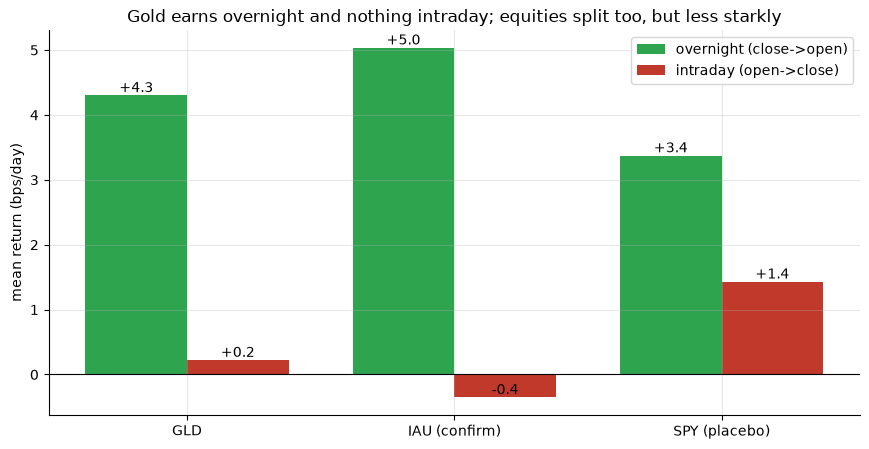

overnight bps/d: [4.3, 5.03, 3.37]   intraday bps/d: [0.22, -0.35, 1.43]


In [3]:
if HAVE_REAL:
    rows = [(nm, st.split_stats(r, placebo=False)) for nm, r in
            (("GLD", GLD), ("IAU", IAU), ("SPY", SPY))]
    ons = [s["on_bps"] for _, s in rows]; ids = [s["id_bps"] for _, s in rows]
else:
    ons = [R[k]["on"] for k in ("gld", "iau", "spy")]
    ids = [R[k]["id"] for k in ("gld", "iau", "spy")]
x = np.arange(3); w = 0.38
fig, ax = plt.subplots(figsize=(8.8, 4.6))
ax.bar(x - w/2, ons, w, color=GREEN, label="overnight (close->open)")
ax.bar(x + w/2, ids, w, color=RED, label="intraday (open->close)")
for i, (a, b) in enumerate(zip(ons, ids)):
    ax.annotate(f"{a:+.1f}", (i - w/2, a), ha="center", va="bottom")
    ax.annotate(f"{b:+.1f}", (i + w/2, b), ha="center", va="bottom")
ax.set_xticks(x); ax.set_xticklabels(["GLD", "IAU (confirm)", "SPY (placebo)"])
ax.axhline(0, c="k", lw=.8)
ax.set_ylabel("mean return (bps/day)")
ax.set_title("Gold earns overnight and nothing intraday; equities split too, but less starkly")
ax.legend(); plt.tight_layout(); plt.show()
print("overnight bps/d:", [round(v, 2) for v in ons], "  intraday bps/d:", [round(v, 2) for v in ids])


IAU **confirms** (+5.0 bps/night vs -0.3 bps/day — even starker than GLD). But look at SPY: equities *also* earn more at night (+3.4 vs +1.4). Gold's night-day gap (**+4.1 bps/day**) is about **twice** the equity one (**+1.9**), but statistically the tape can't swear gold is a different species rather than a louder version of the same market-wide clock effect.

**The only question that pays: could you trade it?** "Hold gold only at night" means buying at every close and selling at every open — **two trades a day, forever**. Here's the net result at realistic costs, against just buying and holding.

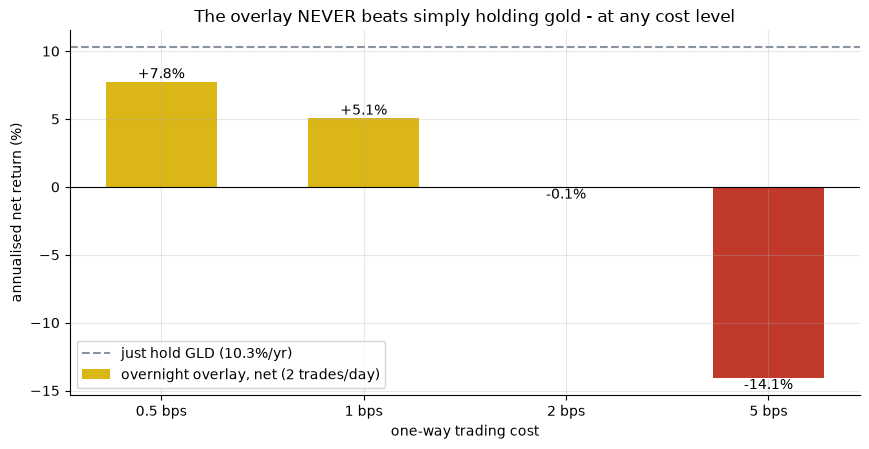

net ann % at [0.5, 1.0, 2.0, 5.0] bps one-way: [7.76, 5.08, -0.08, -14.11]  vs buy&hold 10.31 %


In [4]:
if HAVE_REAL:
    hs = st.harvest_table(GLD)
    costs = [h["cost_bps"] for h in hs]; net = [h["net_ann_pct"] for h in hs]
    bh = hs[0]["bh_ann_pct"]
else:
    costs = [h[0] for h in R["harvest"]]; net = [h[2] for h in R["harvest"]]
    bh = R["harvest"][0][3]
fig, ax = plt.subplots(figsize=(8.8, 4.6))
cols = [GREEN if v >= bh else (AMBER if v > 0 else RED) for v in net]
ax.bar([f"{c:g} bps" for c in costs], net, color=cols, width=.55,
       label="overnight overlay, net (2 trades/day)")
ax.axhline(bh, ls="--", c=GREY, label=f"just hold GLD ({bh:.1f}%/yr)")
ax.axhline(0, c="k", lw=.8)
for i, v in enumerate(net):
    ax.annotate(f"{v:+.1f}%", (i, v), ha="center", va="bottom" if v >= 0 else "top")
ax.set_xlabel("one-way trading cost"); ax.set_ylabel("annualised net return (%)")
ax.set_title("The overlay NEVER beats simply holding gold - at any cost level")
ax.legend(); plt.tight_layout(); plt.show()
print("net ann % at", costs, "bps one-way:", [round(v, 2) for v in net], " vs buy&hold", round(bh, 2), "%")


This is the punchline. Even at an impossibly tight **0.5 bps** per trade the night-only strategy makes **+7.8%/yr — less than the +10.3%/yr you'd get by doing nothing**. At 2 bps it makes roughly zero; at 5 bps it's a disaster. Why? Because the day session you're dodging earns *about zero, not something negative enough to be worth dodging* — so every spread you pay is pure loss. The anomaly tells you **when** gold's return arrives; it doesn't hand you a trade.

## 5 · The verdict

- **Signal — Real.** Gold genuinely made its entire two-decade return overnight ($8.63 vs $0.96 per dollar; solid *t*-stats on both GLD and IAU).
- **Tradability — Mirage.** Two trades a day to dodge a day-session worth zero: the night-only strategy loses to buy & hold at **every** cost level, in **every** sub-period.
- **"Ever harvestable?" — Busted.** Even at spreads tighter than GLD has ever traded, the arithmetic never works. And the bonus finding: the **2015 fix reform didn't dent the pattern** — it *grew* — so the "riggers suppress gold during fix hours" reading loses its engine. The boring truth: gold's price discovery simply happens while New York sleeps.

## 6 · Going further 🚪

- **The equities version of this rabbit hole** is [study 01 — the overnight anomaly](../../01-overnight-anomaly/README.md): same clock split, a manipulation theory of its own (Knuteson), and the same Real-but-Mirage ending.
- **Why does the open capture it?** GLD's NAV moves with spot gold around the clock; the US open is just the first print after 17½ hours of Asian and London trading. A "night return" is mostly *other people's daytime*.
- **Build your own.** Swap in futures (GC=F trades nearly 24h, so its "overnight" is a different animal), or split the day at the London fixes themselves with intraday data — the engine in [`gold_overnight/`](../gold_overnight/) takes any open/close tape.

*Think you can make two-trades-a-day work because your broker charges nothing? Spreads aren't commissions — show the night-only sleeve beating buy & hold net of the **bid-ask**, then we'll talk.*